In [1]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
import os
import pandas as pd
from PIL import Image
from skimage.feature import hog
from skimage import color
from tensorflow import keras
from tensorflow.keras import layers, models

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# import zipfile

# zip_path = "/content/drive/MyDrive/viechle.zip"
# extract_path = "/content/dataset_v"

# if not os.path.exists(extract_path):
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)

BASE = path

train_dir = os.path.join(BASE, 'Train')
filepaths, labels = [], []

for folder in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, folder)
    if os.path.isdir(foldpath):
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(int(folder))

train_df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

# test data
test_csv_path = os.path.join(BASE, 'Test.csv')
test_csv = pd.read_csv(test_csv_path)

test_df = pd.DataFrame({
    'filepath': test_csv['Path'].apply(lambda p: os.path.join(BASE, p)),
    'label': test_csv['ClassId'].astype(int)
})

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 39209
Test size: 12630


In [5]:
CLASS_NAMES = {
    0:'Speed limit 20',    1:'Speed limit 30',     2:'Speed limit 50',
    3:'Speed limit 60',    4:'Speed limit 70',     5:'Speed limit 80',
    6:'End speed 80',      7:'Speed limit 100',    8:'Speed limit 120',
    9:'No passing',       10:'No passing >3.5t',  11:'Right of way jn.',
   12:'Priority road',    13:'Yield',              14:'Stop',
   15:'No vehicles',      16:'No veh >3.5t',      17:'No entry',
   18:'General caution',  19:'Danger curve L',     20:'Danger curve R',
   21:'Double curve',     22:'Bumpy road',         23:'Slippery road',
   24:'Narrow road R',    25:'Road works',         26:'Traffic signals',
   27:'Pedestrians',      28:'Children crossing',  29:'Bicycles crossing',
   30:'Beware of ice',    31:'Wild animals',       32:'End restrictions',
   33:'Turn right ahead', 34:'Turn left ahead',    35:'Ahead only',
   36:'Ahead or right',   37:'Ahead or left',      38:'Keep right',
   39:'Keep left',        40:'Roundabout',         41:'End no passing',
   42:'End no pass >3.5t'
}

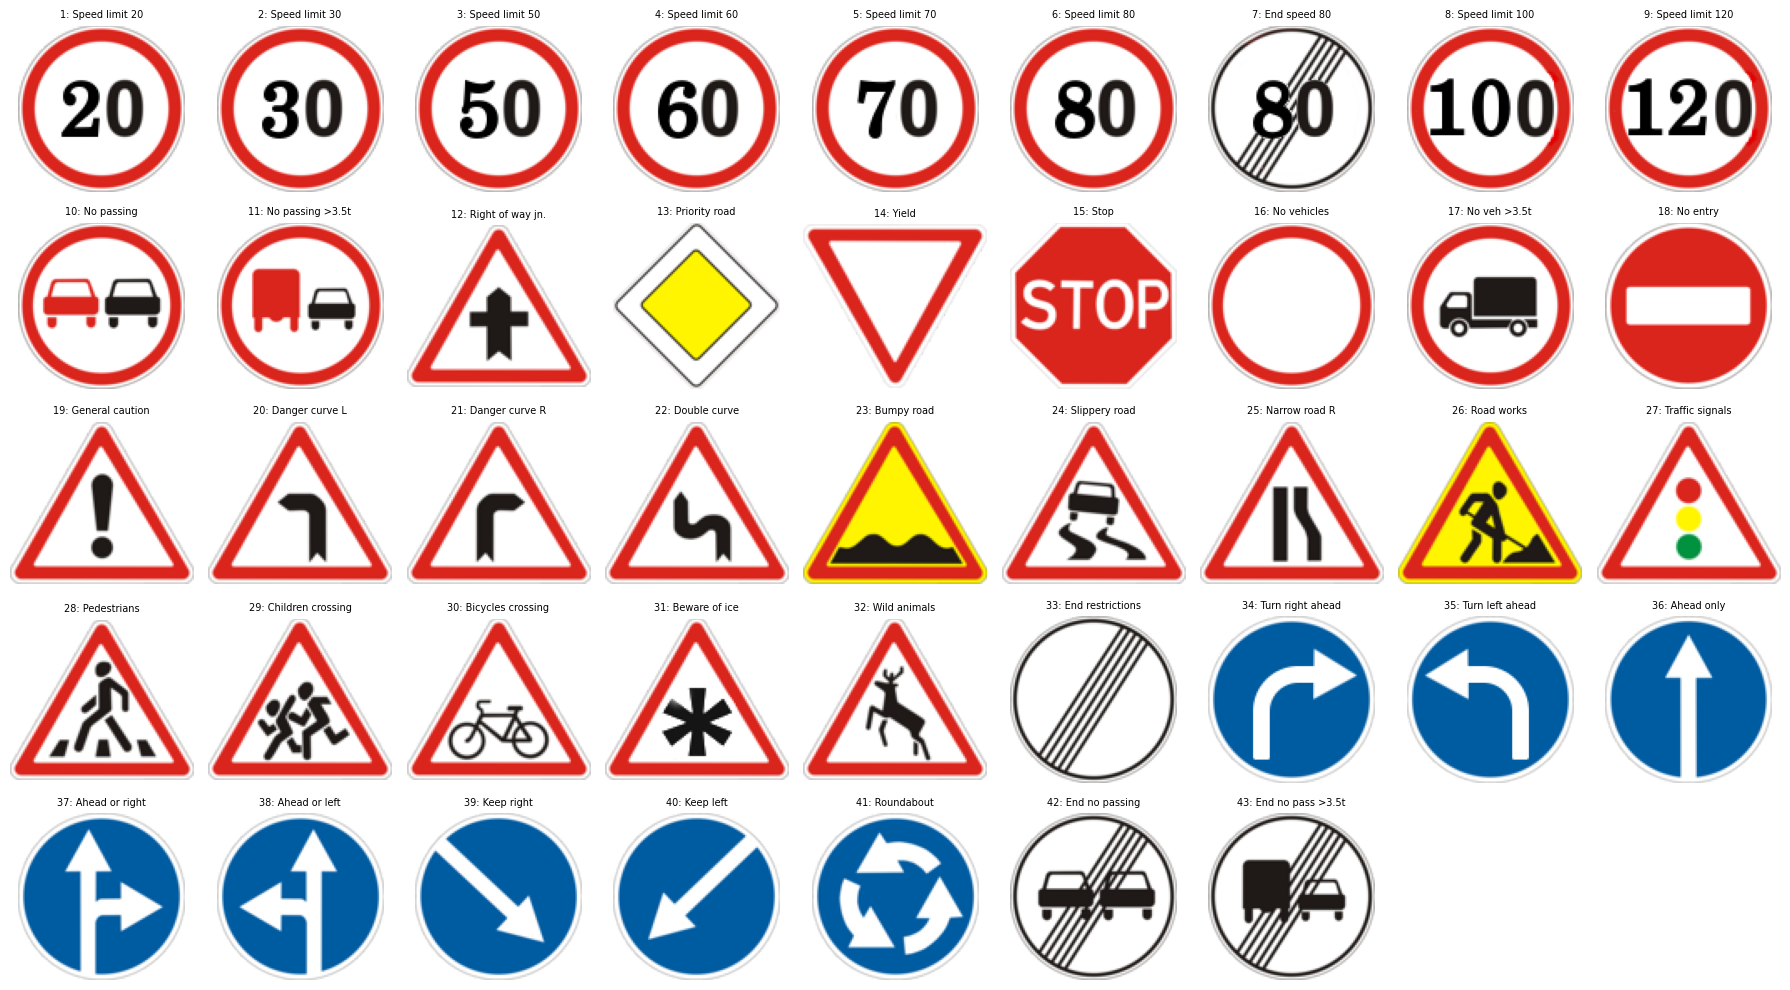

In [6]:
meta_path = os.path.join(BASE, "Meta")

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(43):
    img_path = os.path.join(meta_path, f"{class_id}.png")
    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"{class_id+1}: {CLASS_NAMES[class_id]}", fontsize=7)
    axes[class_id].axis("off")


for i in range(43, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

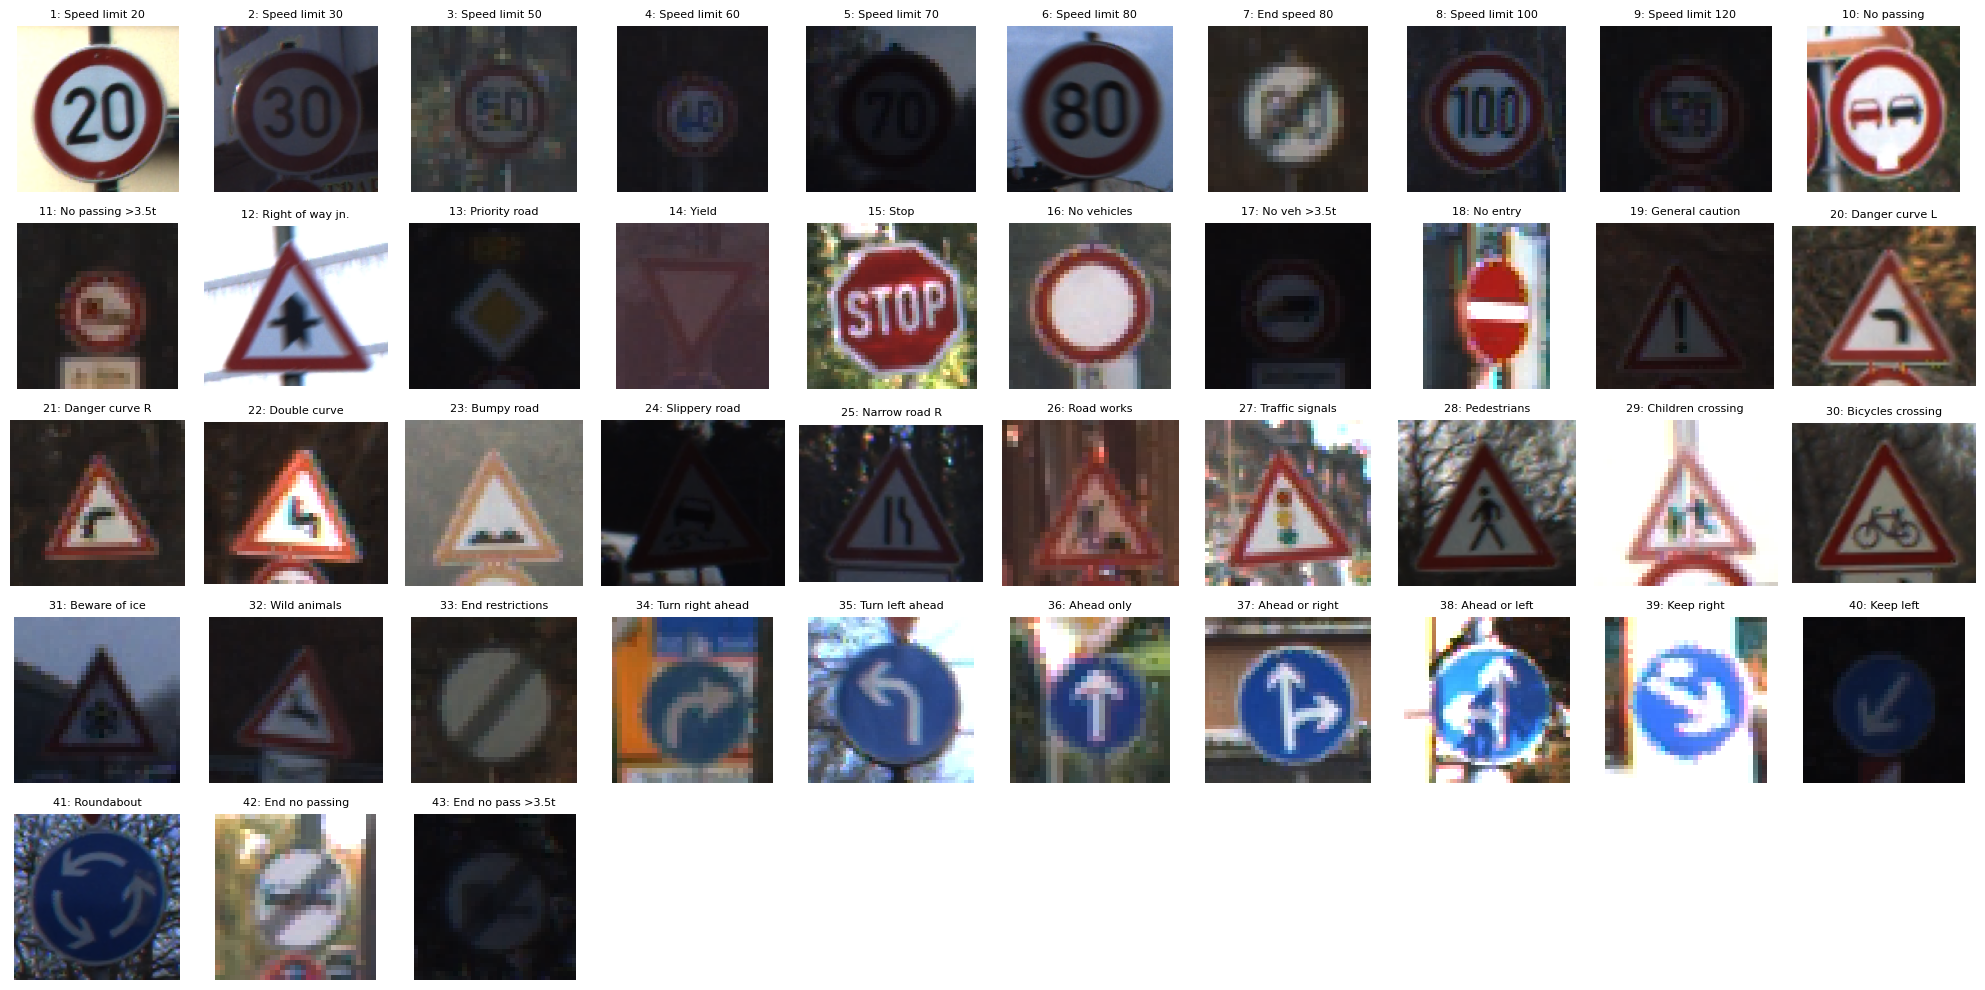

In [7]:
sample_df = train_df.groupby('label').first().reset_index()

n_samples = len(sample_df)

n_cols = 10
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_samples):
    img = Image.open(sample_df['filepath'][i])

    label = sample_df['label'][i]
    class_name = CLASS_NAMES[label]

    axes[i].imshow(img)
    axes[i].set_title(f"{label+1}: {class_name}", fontsize=8)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_13164\587783984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


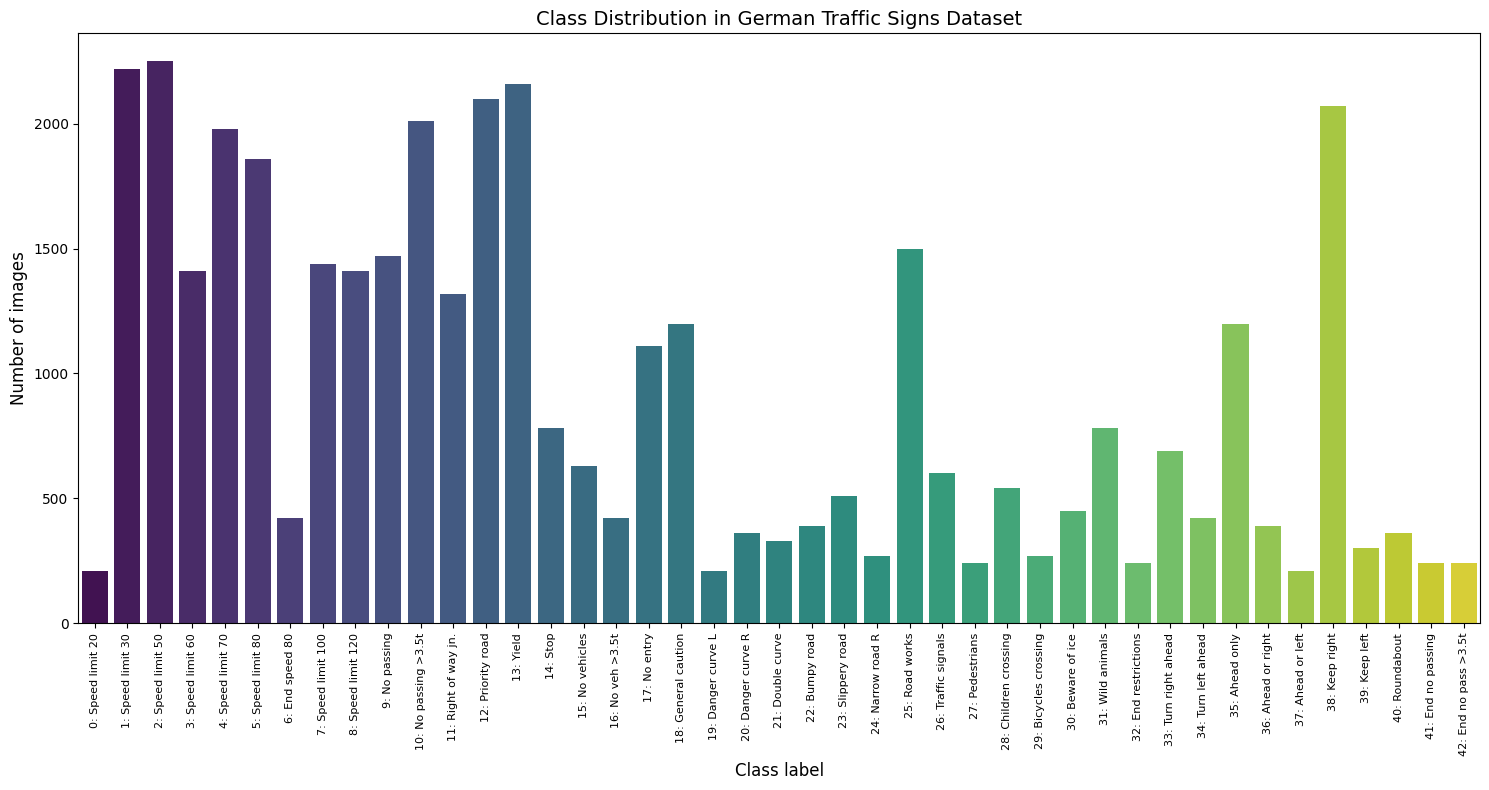

Total images: 39209
Total classes: 43
Average images per class: 911.84
Min images in a class: 210
Max images in a class: 2250


In [ ]:
class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Class Distribution in German Traffic Signs Dataset', fontsize=14)

plt.xticks(ticks=range(len(class_counts)),
           labels=[f"{i}: {CLASS_NAMES[i]}" for i in class_counts.index],
           rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {len(train_df)}")
print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {len(train_df)/len(class_counts):.2f}")
print(f"Min images in a class: {class_counts.min()}")
print(f"Max images in a class: {class_counts.max()}")

In [8]:
def preprocess_image(image_path, size=(32, 32)):
    img = Image.open(image_path)
    img_resized = img.resize(size)
    return np.array(img_resized)

# Extract edges and compute HOG features to capture shape and structure information, which is crucial for traffic sign recognition.
def extract_hog_features(image_array, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=8):
    img_gray = color.rgb2gray(image_array)
    fd = hog(img_gray,
             orientations=orientations,
             pixels_per_cell=pixels_per_cell,
             cells_per_block=cells_per_block,
             block_norm='L2-Hys',
             transform_sqrt=True,
             feature_vector=True)
    return fd

x_train = []
for filepath in train_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_train.append(hog_features)

x_train = np.array(x_train)

x_test = []
for filepath in test_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_test.append(hog_features)

x_test = np.array(x_test)

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Feature vector size: {x_train.shape[1]}")
print(f"Train: {x_train.shape[0]} | Test: {x_test.shape[0]}")

Feature vector size: 288
Train: 39209 | Test: 12630


In [9]:
# Standardize the flattened pixel values
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
save_path = "features"
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "x_train.npy"), x_train)
np.save(os.path.join(save_path, "x_test.npy"), x_test)
np.save(os.path.join(save_path, "y_train.npy"), y_train)
np.save(os.path.join(save_path, "y_test.npy"), y_test)
np.save(os.path.join(save_path, "x_train_scaled.npy"), x_train_scaled)
np.save(os.path.join(save_path, "x_test_scaled.npy"), x_test_scaled)

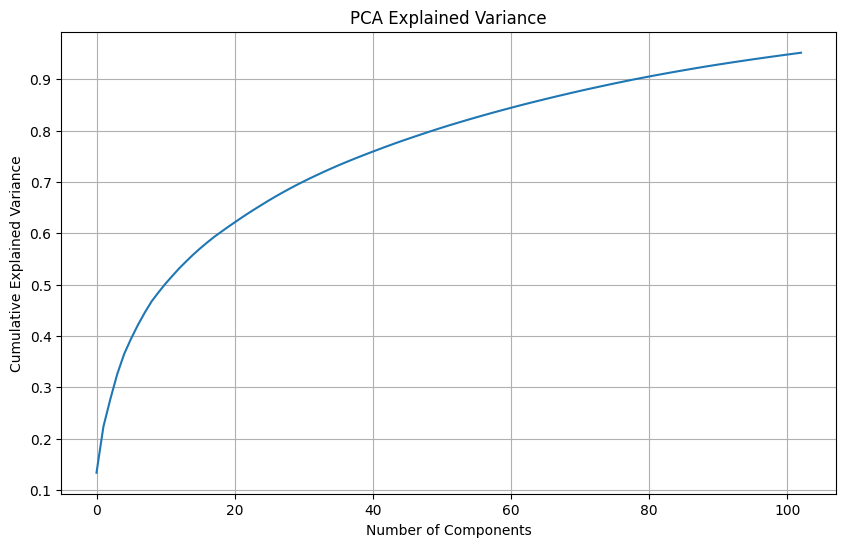

Components selected: 103


In [ ]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [ ]:
# KNN Without PCA
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_scaled, y_train.reshape(-1,))
y_KNN = KNN.predict(x_test_scaled)
print("KNN without PCA Accuracy:", accuracy_score(y_test, y_KNN))

# KNN with PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca,y_train.reshape(-1,))
y_KNN_pca = KNN_pca.predict(x_test_pca)
print("KNN with PCA Accuracy:", accuracy_score(y_test, y_KNN_pca))

KNN without PCA Accuracy: 0.6876484560570071
KNN with PCA Accuracy: 0.6878068091844813


In [ ]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_scaled, y_train.reshape(-1,))
y_ModelNaive = ModelNaive.predict(x_test_scaled)
print("Naive Bayes without PCA Accuracy:", accuracy_score(y_test, y_ModelNaive))

# Naive Bayes with PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train.reshape(-1,))
y_ModelNaive_pca = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA Accuracy:", accuracy_score(y_test, y_ModelNaive_pca))

Naive Bayes without PCA Accuracy: 0.6855106888361046
Naive Bayes with PCA Accuracy: 0.728978622327791


In [ ]:
# --- Without PCA ---
# Hard Voting (majority vote)
voting_clf = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='hard'
)
voting_clf.fit(x_train_scaled, y_train.reshape(-1,))
y_voting = voting_clf.predict(x_test_scaled)
print("Hard Voting without PCA Accuracy:", accuracy_score(y_test, y_voting))

# Soft Voting (average probabilities)
voting_clf_soft = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='soft'
)
voting_clf_soft.fit(x_train_scaled, y_train.reshape(-1,))
y_voting_soft = voting_clf_soft.predict(x_test_scaled)
print("Soft Voting without PCA Accuracy:", accuracy_score(y_test, y_voting_soft))

# --- With PCA ---
# Hard Voting (majority vote)
voting_clf_pca = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='hard'
)
voting_clf_pca.fit(x_train_pca, y_train.reshape(-1,))
y_voting_pca = voting_clf_pca.predict(x_test_pca)
print("Hard Voting with PCA Accuracy:", accuracy_score(y_test, y_voting_pca))

# Soft Voting (average probabilities)
voting_clf_soft_pca = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('nb', GaussianNB())
    ],
    voting='soft'
)
voting_clf_soft_pca.fit(x_train_pca, y_train.reshape(-1,))
y_voting_soft_pca = voting_clf_soft_pca.predict(x_test_pca)
print("Soft Voting with PCA Accuracy:", accuracy_score(y_test, y_voting_soft_pca))

Hard Voting without PCA Accuracy: 0.6733966745843231
Soft Voting without PCA Accuracy: 0.7134600158353127
Hard Voting with PCA Accuracy: 0.7027711797307997
Soft Voting with PCA Accuracy: 0.7522565320665083


In [ ]:
# Bagging with KNN - Without PCA
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10,
    random_state=42
)
bagging_knn.fit(x_train_scaled, y_train.reshape(-1,))
y_bagging_knn = bagging_knn.predict(x_test_scaled)
print("Bagging KNN without PCA Accuracy:", accuracy_score(y_test, y_bagging_knn))

# Bagging with Naive Bayes - Without PCA
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    random_state=42
)
bagging_nb.fit(x_train_scaled, y_train.reshape(-1,))
y_bagging_nb = bagging_nb.predict(x_test_scaled)
print("Bagging NB without PCA Accuracy:", accuracy_score(y_test, y_bagging_nb))

# Bagging with KNN - With PCA
bagging_knn_pca = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10,
    random_state=42
)
bagging_knn_pca.fit(x_train_pca, y_train.reshape(-1,))
y_bagging_knn_pca = bagging_knn_pca.predict(x_test_pca)
print("Bagging KNN with PCA Accuracy:", accuracy_score(y_test, y_bagging_knn_pca))

# Bagging with Naive Bayes - With PCA
bagging_nb_pca = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    random_state=42
)
bagging_nb_pca.fit(x_train_pca, y_train.reshape(-1,))
y_bagging_nb_pca = bagging_nb_pca.predict(x_test_pca)
print("Bagging NB with PCA Accuracy:", accuracy_score(y_test, y_bagging_nb_pca))

Bagging KNN without PCA Accuracy: 0.689944576405384
Bagging NB without PCA Accuracy: 0.686381631037213
Bagging KNN with PCA Accuracy: 0.6907363420427554
Bagging NB with PCA Accuracy: 0.7285035629453682


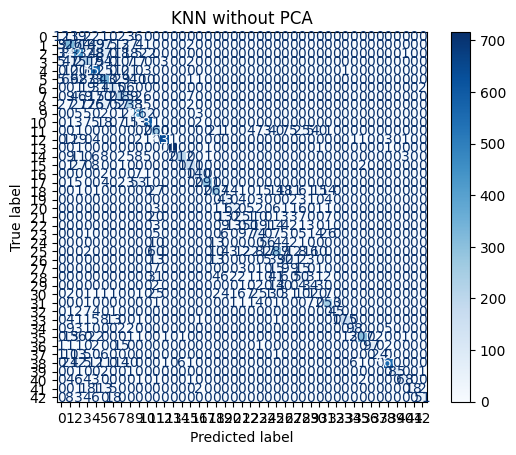

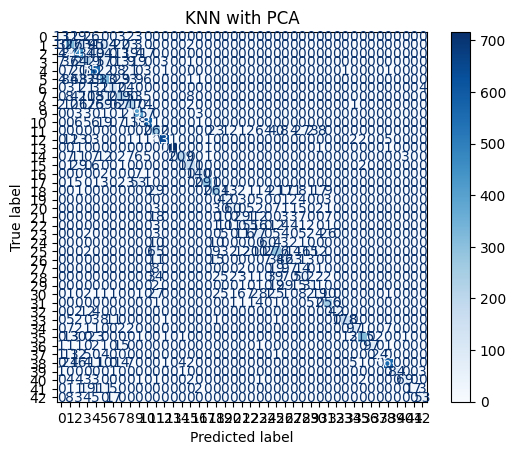

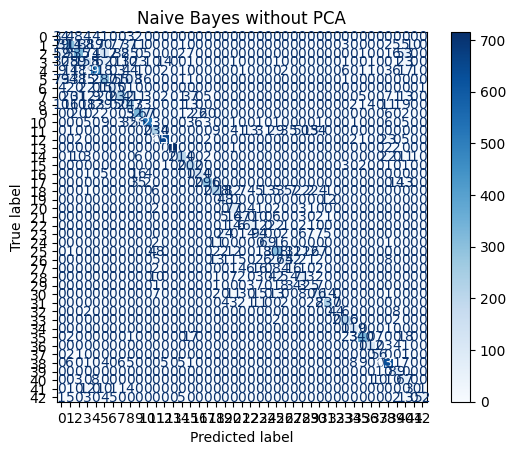

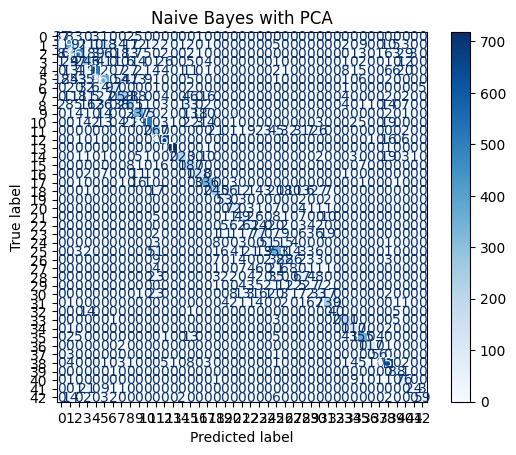

In [ ]:
# Confusion Matrix
def confusion(y, y_pred , title):
    z= confusion_matrix(y, y_pred)
    d= ConfusionMatrixDisplay(confusion_matrix=z)
    d.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

confusion(y_test, y_KNN, "KNN without PCA")
confusion(y_test, y_KNN_pca, "KNN with PCA")

confusion(y_test, y_ModelNaive, "Naive Bayes without PCA")
confusion(y_test, y_ModelNaive_pca, "Naive Bayes with PCA")

In [ ]:
# Loading raw images for CNN input
def load_images(df, size=(32, 32)):
    images = []
    for fp in df['filepath']:
        img = Image.open(fp).resize(size)
        img_array = np.array(img)
        if img_array.ndim == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        if img_array.shape[-1] == 4:
            img_array = img_array[:, :, :3]
        images.append(img_array)
    return np.array(images) / 255.0

x_train_img = load_images(train_df)
x_test_img  = load_images(test_df)
print("Image train shape:", x_train_img.shape)
print("Image test shape :", x_test_img.shape)

Image train shape: (39209, 32, 32, 3)
Image test shape : (12630, 32, 32, 3)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_cnn(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.6970 - loss: 1.0733 - val_accuracy: 0.8762 - val_loss: 0.4199
Epoch 2/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9602 - loss: 0.1247 - val_accuracy: 0.9328 - val_loss: 0.2364
Epoch 3/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9766 - loss: 0.0765 - val_accuracy: 0.9504 - val_loss: 0.2059
Epoch 4/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9853 - loss: 0.0479 - val_accuracy: 0.9492 - val_loss: 0.1854
Epoch 5/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9849 - loss: 0.0492 - val_accuracy: 0.9467 - val_loss: 0.2191
Epoch 6/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9556 - val_loss: 0.1979
Epoch 7/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9887 - loss: 0.0387 - val_accuracy: 0.9498 - val_loss: 0.2241
Epoch 8/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9878 - loss: 0.0434 - 

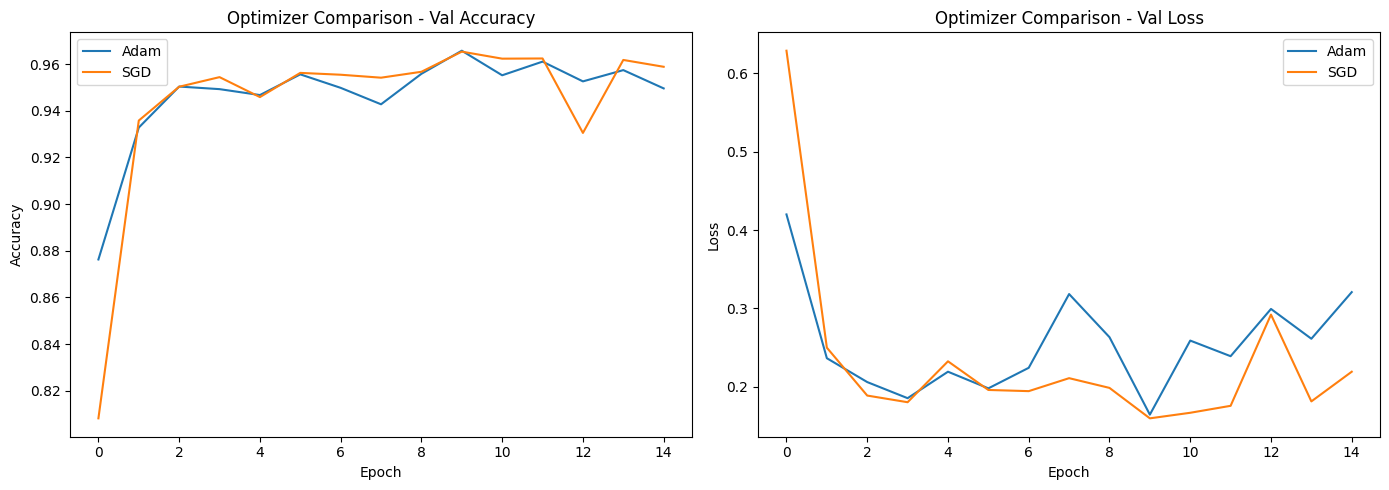

In [ ]:
histories = {}

for name, optimizer in [
    ('Adam', keras.optimizers.Adam()),
    ('SGD',  keras.optimizers.SGD(0.01, momentum=0.9))
]:
    m = build_cnn()
    m.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = m.fit(x_train_img, y_train, epochs=10, batch_size=64, validation_data=(x_test_img, y_test), verbose=1)
    histories[name] = (m, hist)

# Plot comparison
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
for name, (_, h) in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Optimizer Comparison - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
for name, (_, h) in histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.title('Optimizer Comparison - Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


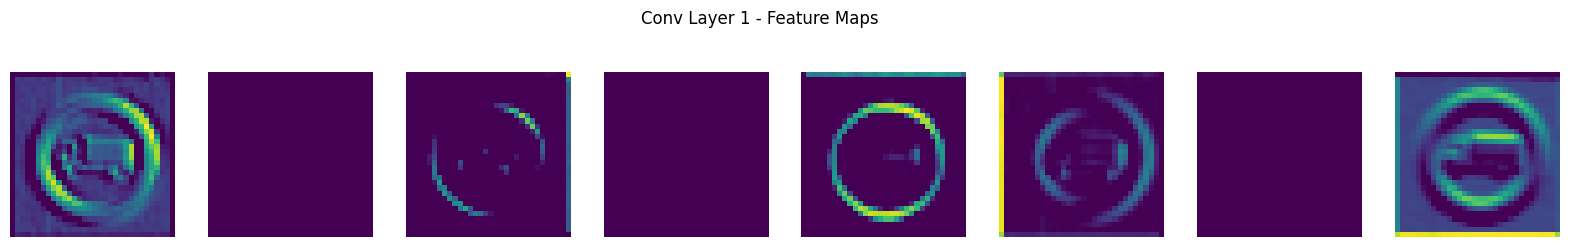

In [ ]:
model = histories['Adam'][0] # Using the best performing model (Adam) for visualization

layer_outputs = [l.output for l in model.layers if 'conv2d' in l.name]
activation_model = keras.Model(inputs=model.inputs, outputs=layer_outputs)

sample = x_test_img[0:1]
activations = activation_model.predict(sample)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(activations[0][0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('Conv Layer 1 - Feature Maps')
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

base_model = MobileNetV2(input_shape=(32,32,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
out = layers.Dense(43, activation='softmax')(x)

mobilenet_model = Model(base_model.input, out)
mobilenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Training with frozen base ---")
hist_frozen = mobilenet_model.fit(x_train_img, y_train, epochs=10, batch_size=64, validation_data=(x_test_img, y_test))

print("--- Fine-tuning (unfrozen) ---")
base_model.trainable = True
mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_ft = mobilenet_model.fit(x_train_img, y_train, epochs=5, batch_size=64, validation_data=(x_test_img, y_test))

C:\Users\PC\AppData\Local\Temp\ipykernel_13164\1699086595.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32,32,3), include_top=False, weights='imagenet')


--- Training with frozen base ---
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2606 - loss: 2.6790 - val_accuracy: 0.2859 - val_loss: 2.4942
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3368 - loss: 2.2450 - val_accuracy: 0.3062 - val_loss: 2.4190
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3654 - loss: 2.1282 - val_accuracy: 0.2998 - val_loss: 2.4246
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3840 - loss: 2.0539 - val_accuracy: 0.3066 - val_loss: 2.4041
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3995 - loss: 1.9970 - val_accuracy: 0.3116 - val_loss: 2.3956
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4122 - loss: 1.9498 - val_accuracy: 0.3137 - val_loss: 2.4110
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.4223 - loss: 1.9104 - val_accuracy: 0.3110 - val_loss: 2.4066
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - 

In [ ]:
scaler = MinMaxScaler()
x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

# NOISE
def gaussian_noise(features, noise_factor):
    noisy_features = features + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=features.shape)
    noisy_features = np.clip(noisy_features, 0., 1.)
    return noisy_features

# salt and peper noise
def salt_peper(features, dropout_rate):
    noisy_features = np.copy(features)
    mask = np.random.binomial(1, 1 - dropout_rate, size=features.shape)
    noisy_features = noisy_features * mask
    return noisy_features

x_train_noisy = gaussian_noise(x_train_normalized, noise_factor=0.4)
x_train_noisy = salt_peper(x_train_noisy, dropout_rate=0.2)

x_test_noisy = gaussian_noise(x_test_normalized, noise_factor=0.4)
x_test_noisy = salt_peper(x_test_noisy, dropout_rate=0.2)

print(f"Noisy train features shape: {x_train_noisy.shape}")
print(f"Noisy test features shape: {x_test_noisy.shape}")

Noisy train features shape: (39209, 288)
Noisy test features shape: (12630, 288)


In [ ]:
def build_dense_autoencoder(input_dim):
    input_layer = layers.Input(shape=(input_dim,))

    # Encoding layers
    encoded = layers.Dense(256, activation='relu')(input_layer)
    encoded = layers.Dense(128, activation='relu')(encoded)
    encoded = layers.Dense(64, activation='relu')(encoded)

    # Decoding layers
    decoded = layers.Dense(128, activation='relu')(encoded)
    decoded = layers.Dense(256, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = keras.Model(input_layer, decoded)

    return autoencoder

feature_dim = x_train.shape[1]
autoencoder = build_dense_autoencoder(feature_dim)
autoencoder.summary()

# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse',
)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 288)            │        74,016 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,496 (900.38 KB)

 Trainable params: 230,496 (900.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train_normalized,
    epochs=100,
    batch_size=120,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_normalized),
    verbose=1
)

Epoch 1/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0303 - val_loss: 0.0238
Epoch 2/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0227 - val_loss: 0.0219
Epoch 3/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0211 - val_loss: 0.0212
Epoch 4/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0203 - val_loss: 0.0209
Epoch 5/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0198 - val_loss: 0.0204
Epoch 6/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0193 - val_loss: 0.0202
Epoch 7/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0189 - val_loss: 0.0201
Epoch 8/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0186 - val_loss: 0.0199
Epoch 9/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0183 - val_loss: 0.0199
Epoch 10/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0181 - val_loss: 0.0199
Epoch 11/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0178 - val_loss: 0.0198
Epoch 12/100
327/327 ━━━━━━━━━━━━━━━━━━━━

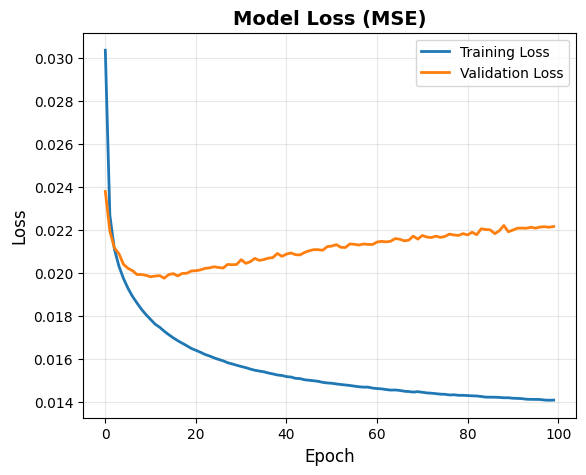

In [ ]:
# Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


Generating reconstructed features
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step


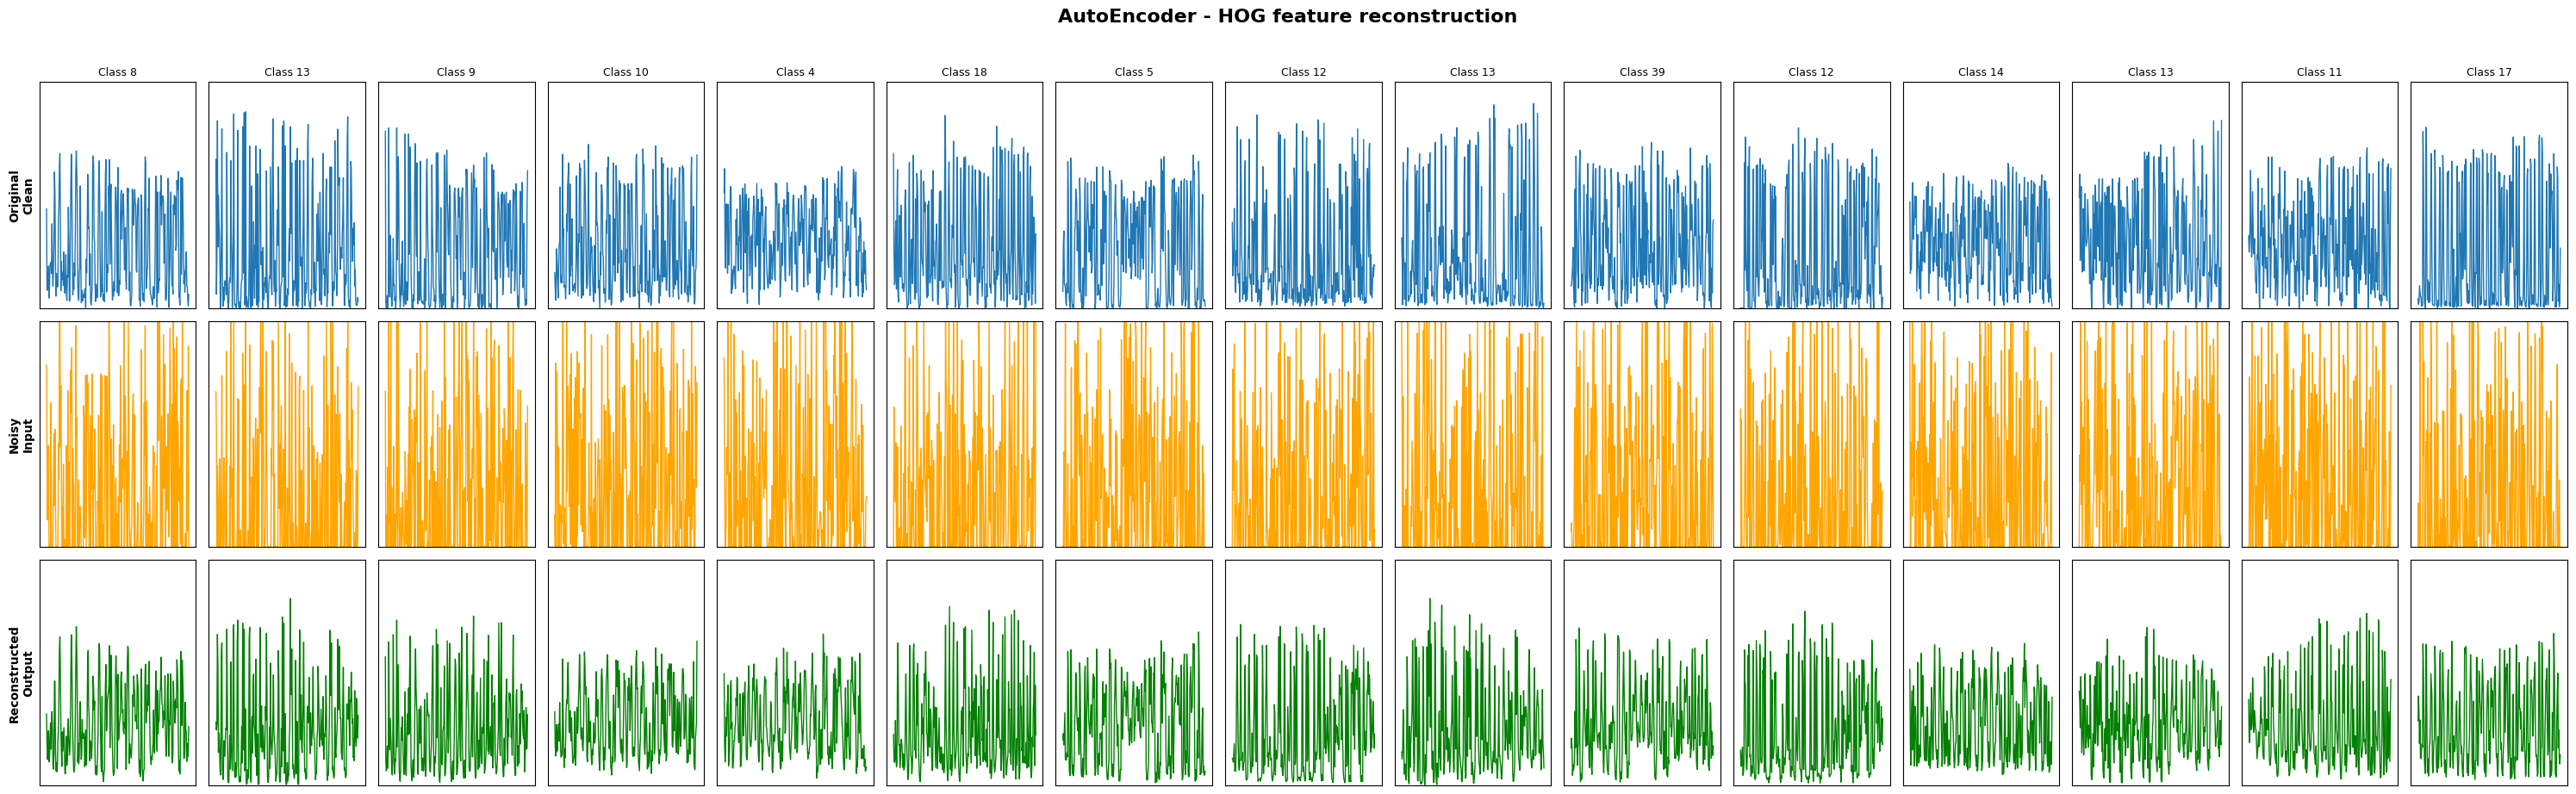

In [ ]:
print("\nGenerating reconstructed features")
x_train_reconstructed = autoencoder.predict(x_train_noisy)
x_test_reconstructed = autoencoder.predict(x_test_noisy)

n_samples = 15
sample_indices = np.random.choice(len(x_test_normalized), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(30, 9))

for i, idx in enumerate(sample_indices):
    #clean features
    axes[0, i].plot(x_test_normalized[idx], linewidth=1)
    axes[0, i].set_ylim([0, 1])
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    if i == 0:
        axes[0, i].set_ylabel('Original\nClean', fontsize=10, fontweight='bold')

    #Noisy features
    axes[1, i].plot(x_test_noisy[idx], linewidth=1, color='orange')
    axes[1, i].set_ylim([0, 1])
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    if i == 0:
        axes[1, i].set_ylabel('Noisy\nInput', fontsize=10, fontweight='bold')

    # Reconstructed Features
    axes[2, i].plot(x_test_reconstructed[idx], linewidth=1, color='green')
    axes[2, i].set_ylim([0, 1])
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])
    if i == 0:
        axes[2, i].set_ylabel('Reconstructed\nOutput', fontsize=10, fontweight='bold')

    axes[0, i].set_title(f'Class {y_test[idx]}', fontsize=9)

plt.suptitle('AutoEncoder - HOG feature reconstruction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_train = np.mean((x_train_normalized - x_train_reconstructed) ** 2)

mse_test = np.mean((x_test_normalized - x_test_reconstructed) ** 2)

In [ ]:
print(f"\n{'='*60}")
print(f"PERFORMANCE - HOG feature Reconstruction")
print(f"{'='*60}")
print(f"Training Set:")
print(f"  Mean squared error : {mse_train:.6f}")
print(f"\nTest Set:")
print(f"  Mean squared error : {mse_test:.6f}")
print(f"{'='*60}")


PERFORMANCE - HOG feature Reconstruction
Training Set:
  Mean squared error : 0.013915

Test Set:
  Mean squared error : 0.022161


In [ ]:
import joblib
import json

# Paths
base_path = ""
model_path = os.path.join(base_path, "models")
os.makedirs(model_path, exist_ok=True)

# 1. Save Autoencoder Model
autoencoder.save(os.path.join(model_path, "autoencoder.h5"))

# 2. Save Encoder Only (Feature Extractor)
encoder = keras.Model(autoencoder.input, autoencoder.layers[3].output)
encoder.save(os.path.join(model_path, "encoder.h5"))

# 3. Save Scaler
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))

# 4. Save Reconstructed Features
features_path = os.path.join(base_path, "features")

np.save(os.path.join(features_path, "x_train_reconstructed.npy"), x_train_reconstructed)
np.save(os.path.join(features_path, "x_test_reconstructed.npy"), x_test_reconstructed)

# 5. Save Noisy Data
np.save(os.path.join(features_path, "x_train_noisy.npy"), x_train_noisy)
np.save(os.path.join(features_path, "x_test_noisy.npy"), x_test_noisy)

# 6. Save Training History
with open(os.path.join(base_path, "history.json"), "w") as f:
    json.dump(history.history, f)

# 7. Save Metrics
with open(os.path.join(base_path, "results.txt"), "w") as f:
    f.write(f"Train MSE: {mse_train}\n")
    f.write(f"Test MSE: {mse_test}\n")

print("All new components saved successfully!")

All new components saved successfully!


## CNN Model (Core Model Builder)

In [11]:
from tensorflow import keras
from tensorflow.keras import layers, models

In [12]:
# Loading raw images for CNN input
def load_images(df, size=(32, 32)):
    images = []
    for fp in df['filepath']:
        img = Image.open(fp).resize(size)
        img_array = np.array(img)
        if img_array.ndim == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        if img_array.shape[-1] == 4:
            img_array = img_array[:, :, :3]
        images.append(img_array)
    return np.array(images) / 255.0

x_train_img = load_images(train_df)
x_test_img  = load_images(test_df)
print("Image train shape:", x_train_img.shape)
print("Image test shape :", x_test_img.shape)

Image train shape: (39209, 32, 32, 3)
Image test shape : (12630, 32, 32, 3)


In [13]:
def CNN_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [14]:
def CNN_Deep_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [15]:
def CNN_K5(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [16]:
models_dict = {
    "CNN_Model": CNN_Model(),
    "CNN_Deep_Model": CNN_Deep_Model(),
    "CNN_K5": CNN_K5()
}

h = {}
trained = {}
for name, model in models_dict.items():
    print(f"\nTraining {name} ...")

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_img, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(x_test_img, y_test),
        verbose=1
    )

    h[name] = history
    trained[name] = model


Training CNN_Model ...
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.7065 - loss: 1.0694 - val_accuracy: 0.8532 - val_loss: 0.6503
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.9607 - loss: 0.1554 - val_accuracy: 0.8862 - val_loss: 0.5217
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9797 - loss: 0.0819 - val_accuracy: 0.9043 - val_loss: 0.4471
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 62s 101ms/step - accuracy: 0.9893 - loss: 0.0427 - val_accuracy: 0.8892 - val_loss: 0.5548
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9902 - loss: 0.0360 - val_accuracy: 0.9164 - val_loss: 0.4308
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 62s 101ms/step - accuracy: 0.9923 - loss: 0.0295 - val_accuracy: 0.9013 - val_loss: 0.4895
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 61s 99ms/step - accuracy: 0.9936 - loss: 0.0243 - val_accuracy: 0.9341 - val_loss: 0.3637
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accu

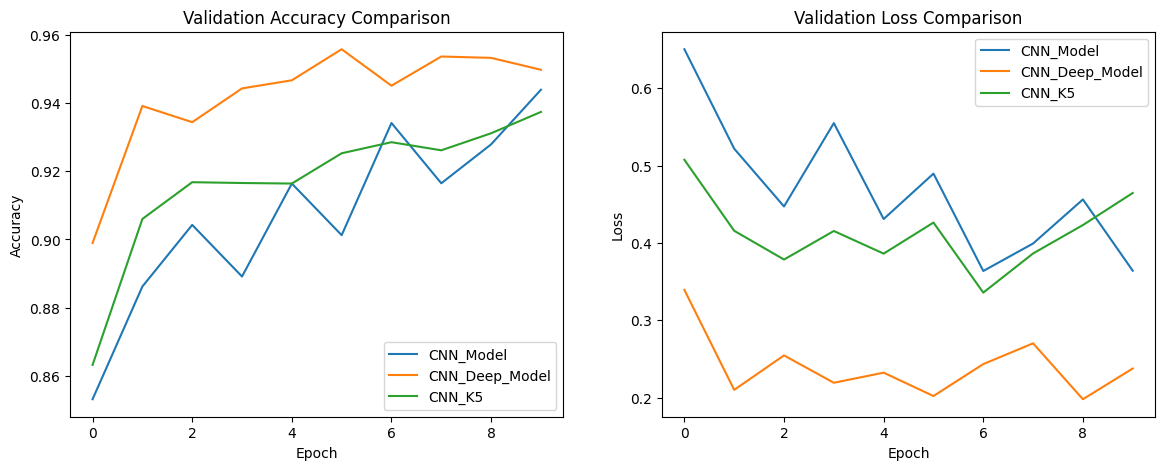

In [17]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
for name, x in h.items():
    plt.plot(x.history['val_accuracy'], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
for name, x in h.items():
    plt.plot(x.history['val_loss'], label=name)
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Best Model: CNN_Deep_Model
395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step


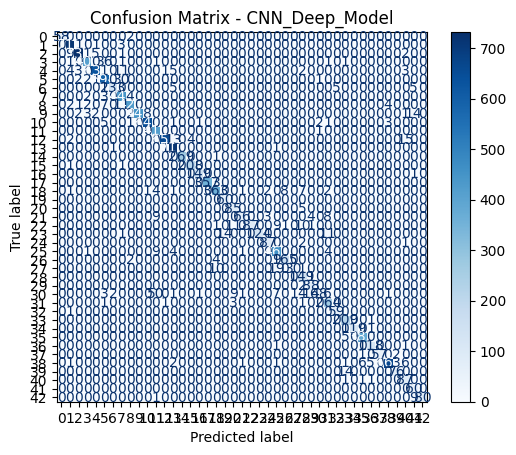

In [20]:
best_model_name = max(h, key=lambda x: max(h[x].history['val_accuracy']))
best_model = trained[best_model_name]
print("Best Model:", best_model_name)
y_pred = best_model.predict(x_test_img)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()